In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os

sys.path.append('C:/Users/madel/Code/GeoNorth')

from utils import *

TOTSOILICE = lndgrid (no levels)

SOILICE = levsoi

(SOILLIQ/1000+SOILICE/920)/deltazi = H2OSOI

In [2]:
site = "TVC"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
df

C:\Users\madel\AppData\Local\Temp\ipykernel_37236\3973305985.py:3: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


<xarray.Dataset> Size: 14MB
Dimensions:                        (time: 7300, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 58kB 1995-01-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 29kB ...
    mcsec                          (time) int32 29kB ...
    mdcur                          (time) int32 29kB ...
    mscur                          (time) int32 29kB ...
    nstep                          (time) int32 29kB ...
    time_bounds                    (time, hist_interval) object 117kB ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 584kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 263kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 438kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 117kB ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:29:19 2026: ncrcat TV...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

In [4]:
print(df['DZSOI'].values)

[[ 0.02     ]
 [ 0.04     ]
 [ 0.06     ]
 [ 0.08     ]
 [ 0.12     ]
 [ 0.16     ]
 [ 0.2      ]
 [ 0.24     ]
 [ 0.28     ]
 [ 0.32     ]
 [ 0.36     ]
 [ 0.4      ]
 [ 0.44     ]
 [ 0.54     ]
 [ 0.64     ]
 [ 0.74     ]
 [ 0.84     ]
 [ 0.94     ]
 [ 1.04     ]
 [ 1.14     ]
 [ 2.39     ]
 [ 4.675534 ]
 [ 7.6351905]
 [11.14     ]
 [15.115425 ]]


In [5]:
print(df['levsoi'].values)

[0.01 0.04 0.09 0.16 0.26 0.4  0.58 0.8  1.06 1.36 1.7  2.08 2.5  2.99
 3.58 4.27 5.06 5.95 6.94 8.03]


In [125]:
vari = "TOTSOILICE"

In [126]:
ds_totice = df["TOTSOILICE"]
ds_totliq = df["TOTSOILLIQ"]
ds_sm = df["H2OSOI"]
ds_sm_l = df["SOILLIQ"]
ds_sm_i = df["SOILICE"]
dz = df["DZSOI"]

In [127]:
ds_sm.sel(levsoi=0.09, method='nearest')

<xarray.DataArray 'H2OSOI' (time: 7300, lndgrid: 1)> Size: 29kB
[7300 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
    levsoi   float32 4B 0.09
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

(SOILLIQ/1000+SOILICE/920)/deltazi = H2OSOI

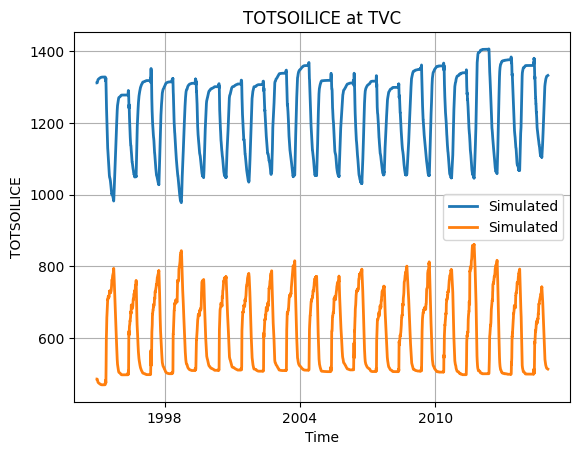

In [128]:
plt.plot(
    ds_totice["time"].values,
    ds_totice.values,
    label=f"Simulated",
    linewidth=2
)

plt.plot(
    ds_totliq["time"].values,
    ds_totliq.values,
    label=f"Simulated",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel(f"{vari}")
plt.title(f"{vari} at {site}")
plt.grid(True)
plt.legend()

In [129]:
ds_totice

<xarray.DataArray 'TOTSOILICE' (time: 7300, lndgrid: 1)> Size: 29kB
array([[1311.5784],
       [1311.5784],
       [1311.5784],
       ...,
       [1331.7018],
       [1332.0077],
       [1332.1758]], shape=(7300, 1), dtype=float32)
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      vertically summed soil ice (veg landunits only)
    units:          kg/m2
    cell_methods:   time: mean
    landunit_mask:  veg

In [130]:
ds_totliq

<xarray.DataArray 'TOTSOILLIQ' (time: 7300, lndgrid: 1)> Size: 29kB
array([[485.69824],
       [485.69824],
       [485.6982 ],
       ...,
       [514.0896 ],
       [513.7827 ],
       [513.6148 ]], shape=(7300, 1), dtype=float32)
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      vertically summed soil liquid water (veg landunits only)
    units:          kg/m2
    cell_methods:   time: mean
    landunit_mask:  veg

In [131]:
ice = ds_sm_i.sel(levsoi=0.09, method='nearest')
liquid = ds_sm_l.sel(levsoi=0.09, method='nearest')

convert_hsoi = (liquid/1000 + ice/920)*dz.sel(levgrnd=0.09, method='nearest')

In [136]:
def plot_h2osoi(dz, ds_sm_i, ds_sm_l, sim, site, depths, vari, show=0):

    for x in depths:

        plt.figure(figsize=(14,6))

        print(x)
        
        ice = ds_sm_i.sel(levsoi=x, method='nearest')
        liquid = ds_sm_l.sel(levsoi=x, method='nearest')
        delta = dz.sel(levgrnd=x, method='nearest')

        convert_hsoi = (liquid/1000 + ice/920)/delta
        liq_hsoi = liquid/delta/1000
        ice_hsoi = ice/delta/920

        test_hsoi = liq_hsoi + ice_hsoi

        # plt.plot(
        #     liquid["time"].values,
        #     convert_hsoi.values,
        #     label=f"Observed - {x*100:.0f}cm",
        #     linewidth=2
        # )


        plt.plot(
            test_hsoi["time"].values,
            test_hsoi.values,
            label=f"Observed - {x*100:.0f}cm",
            linewidth=2
        )

        # Simulated
        
        plt.plot(
            sim["time"].values,
            sim.sel(levsoi=x, method = "nearest").values,
            label=f"Simulated - {x*100:.0f}cm",
            linewidth=2
        )
    
        plt.xlabel("Time")
        plt.ylabel(f"{vari}")
        plt.title(f"{vari} at {site}")
        plt.grid(True)
        plt.legend()
        if not show:
            plt.close()

<xarray.DataArray 'levsoi' ()> Size: 4B
array(0.01, dtype=float32)
Coordinates:
    levsoi   float32 4B 0.01
Attributes:
    long_name:  coordinate soil levels (equivalent to top nlevsoi levels of l...
    units:      m
<xarray.DataArray 'levsoi' ()> Size: 4B
array(0.04, dtype=float32)
Coordinates:
    levsoi   float32 4B 0.04
Attributes:
    long_name:  coordinate soil levels (equivalent to top nlevsoi levels of l...
    units:      m
<xarray.DataArray 'levsoi' ()> Size: 4B
array(0.09, dtype=float32)
Coordinates:
    levsoi   float32 4B 0.09
Attributes:
    long_name:  coordinate soil levels (equivalent to top nlevsoi levels of l...
    units:      m
<xarray.DataArray 'levsoi' ()> Size: 4B
array(0.16, dtype=float32)
Coordinates:
    levsoi   float32 4B 0.16
Attributes:
    long_name:  coordinate soil levels (equivalent to top nlevsoi levels of l...
    units:      m
<xarray.DataArray 'levsoi' ()> Size: 4B
array(0.26, dtype=float32)
Coordinates:
    levsoi   float32 4B 0.26
Attributes:

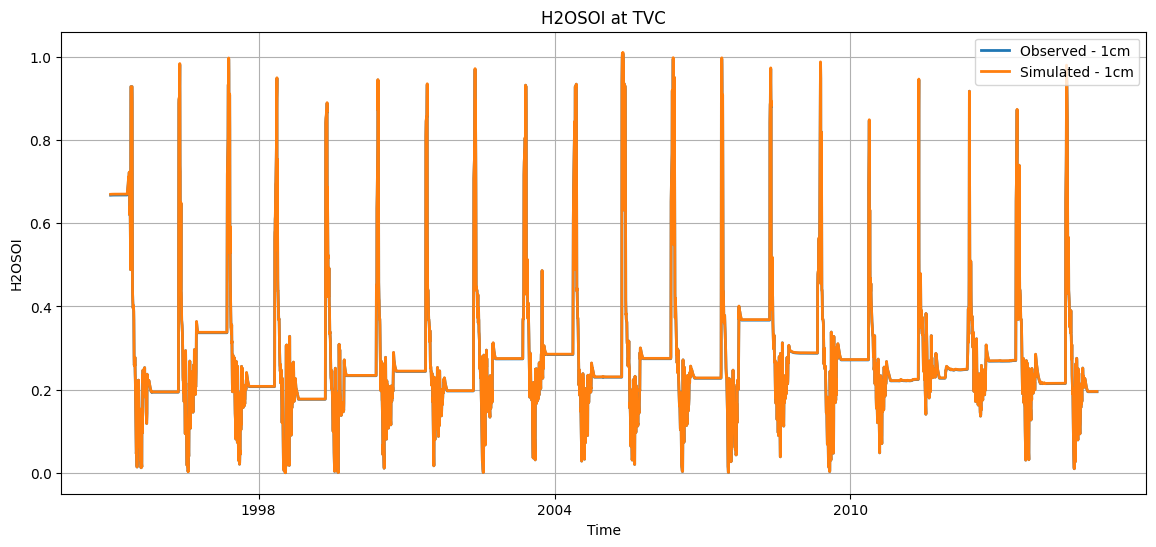

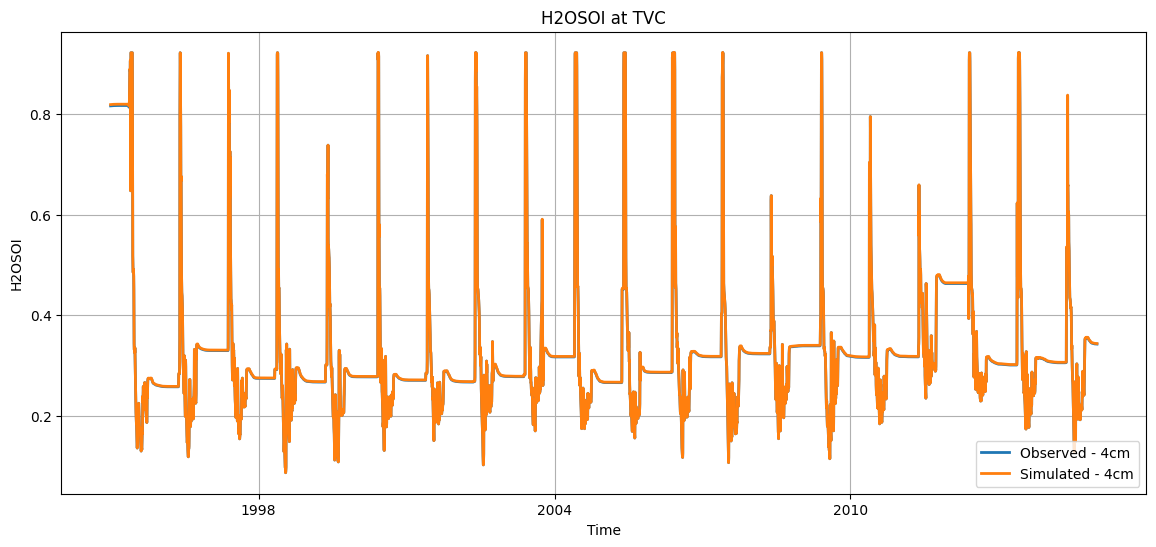

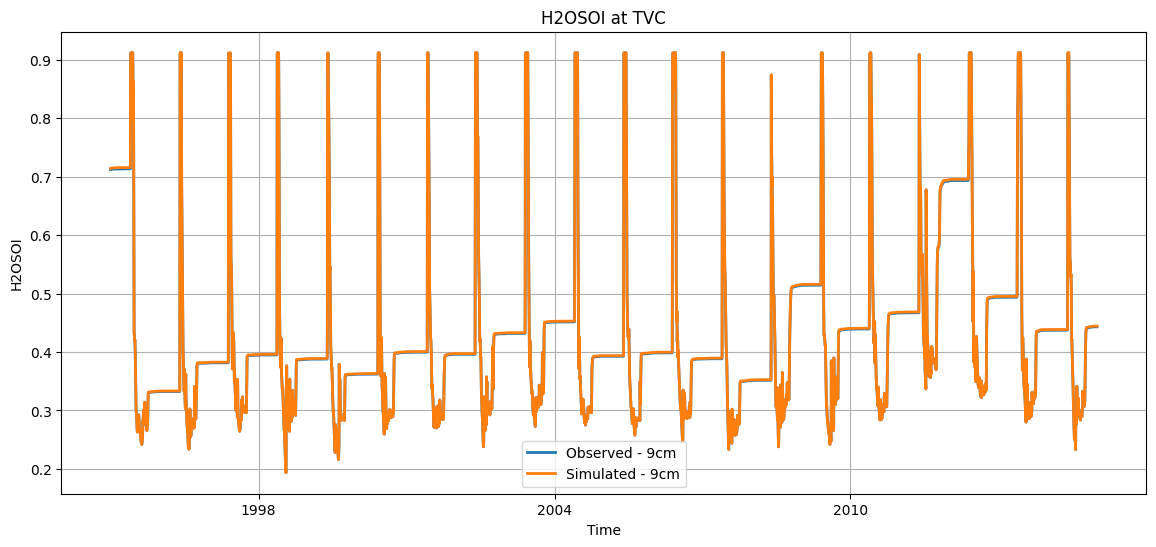

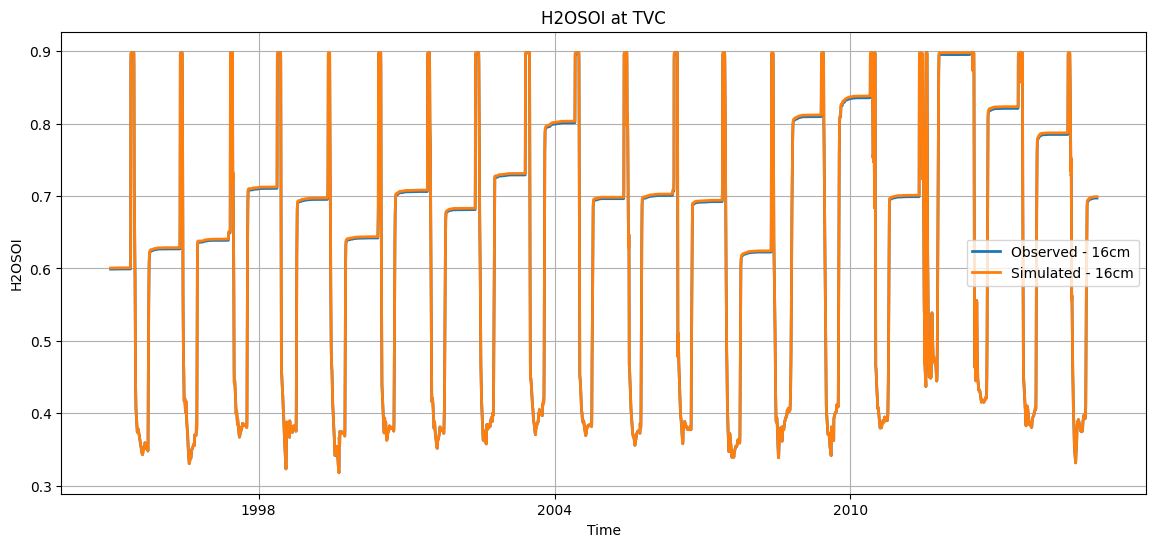

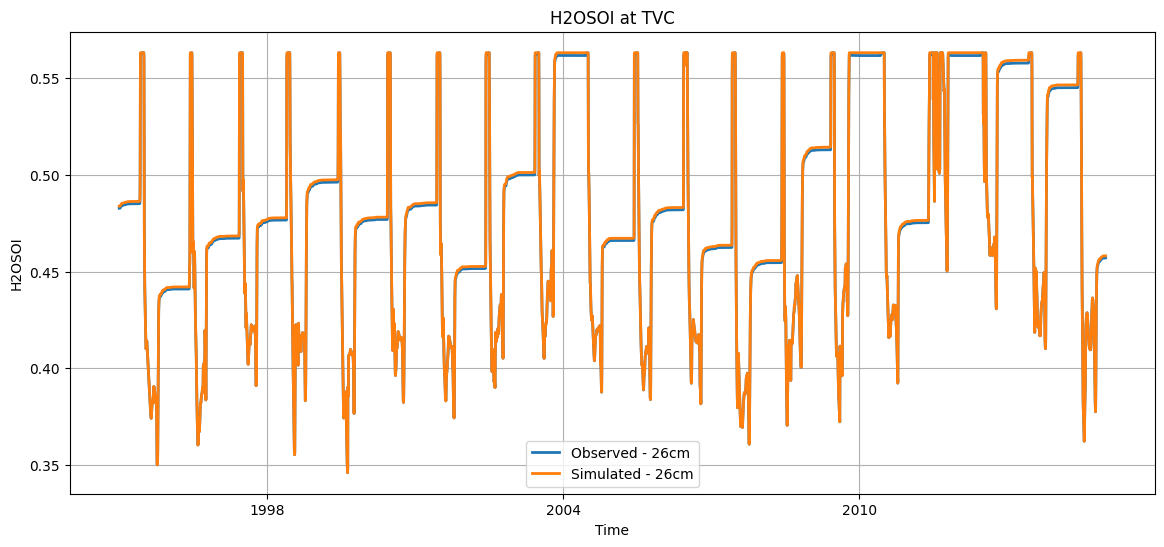

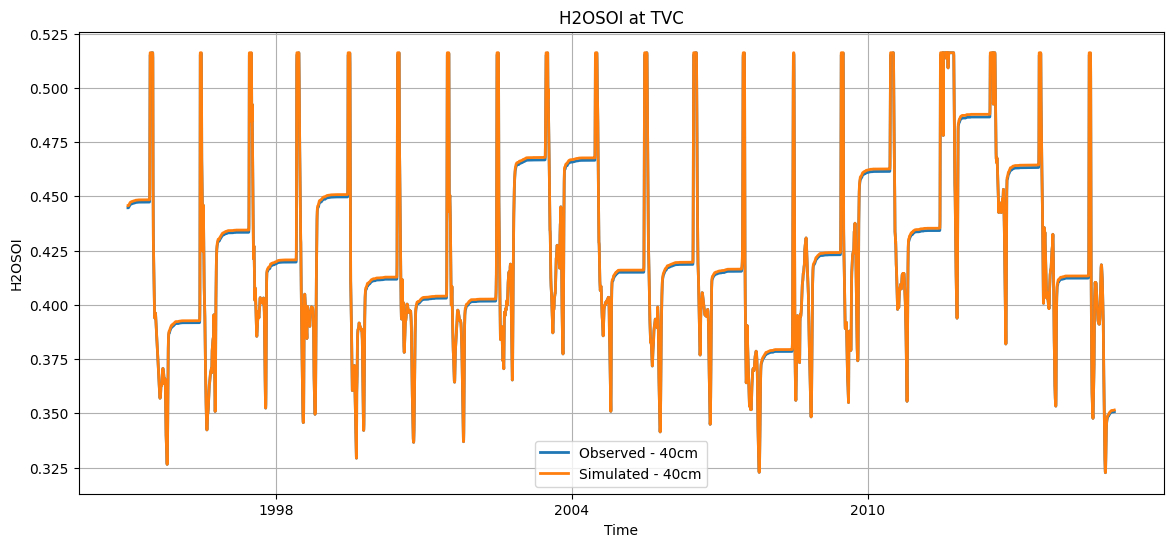

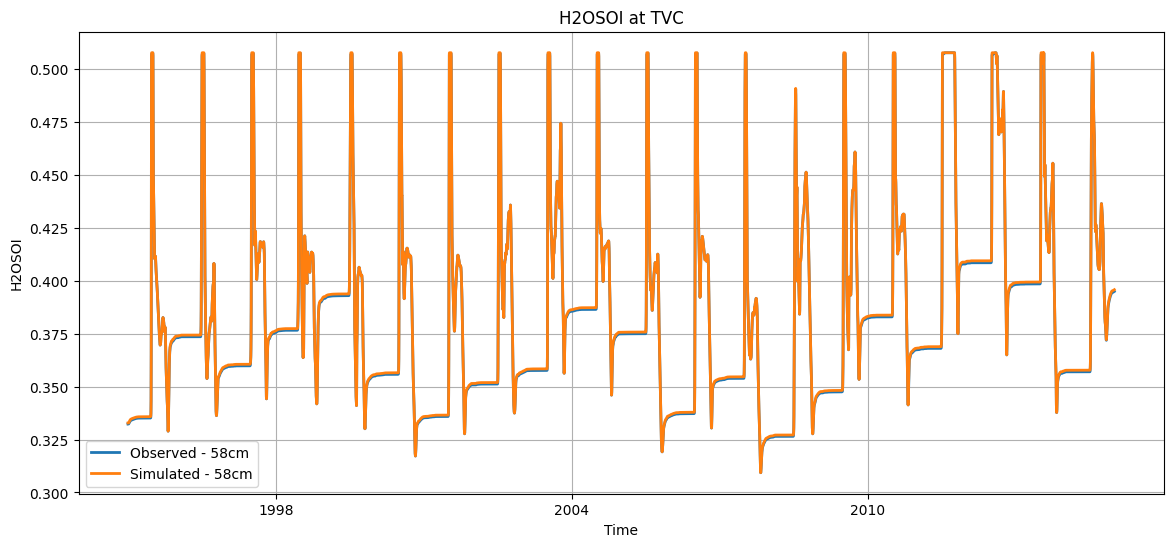

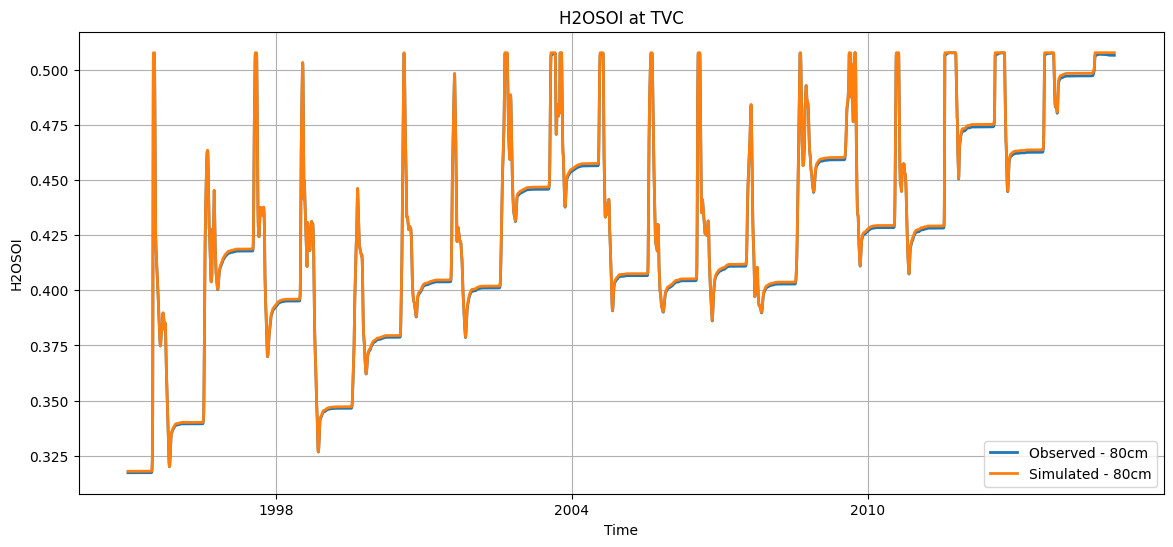

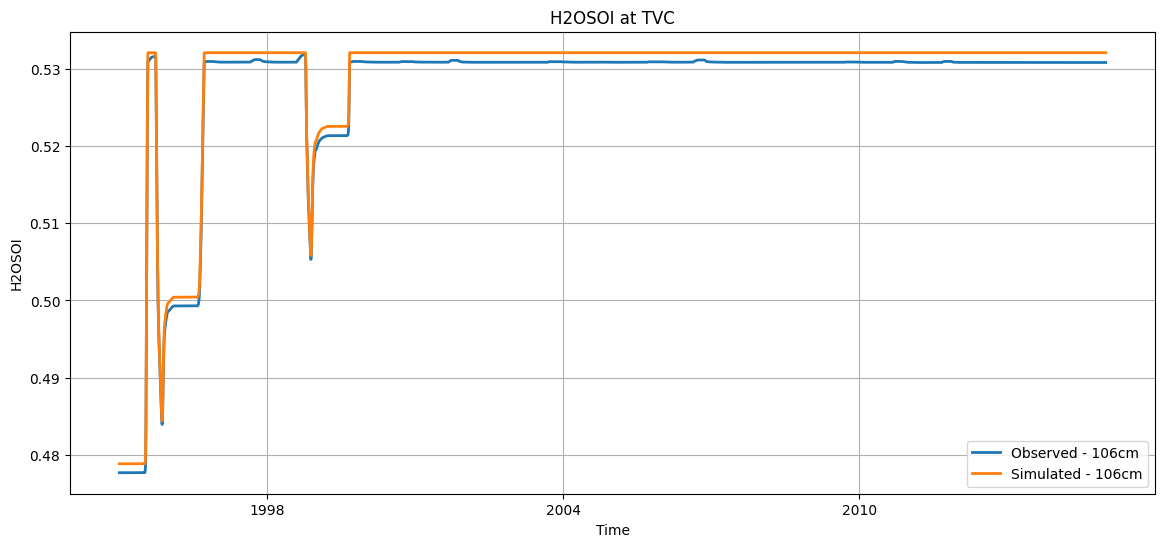

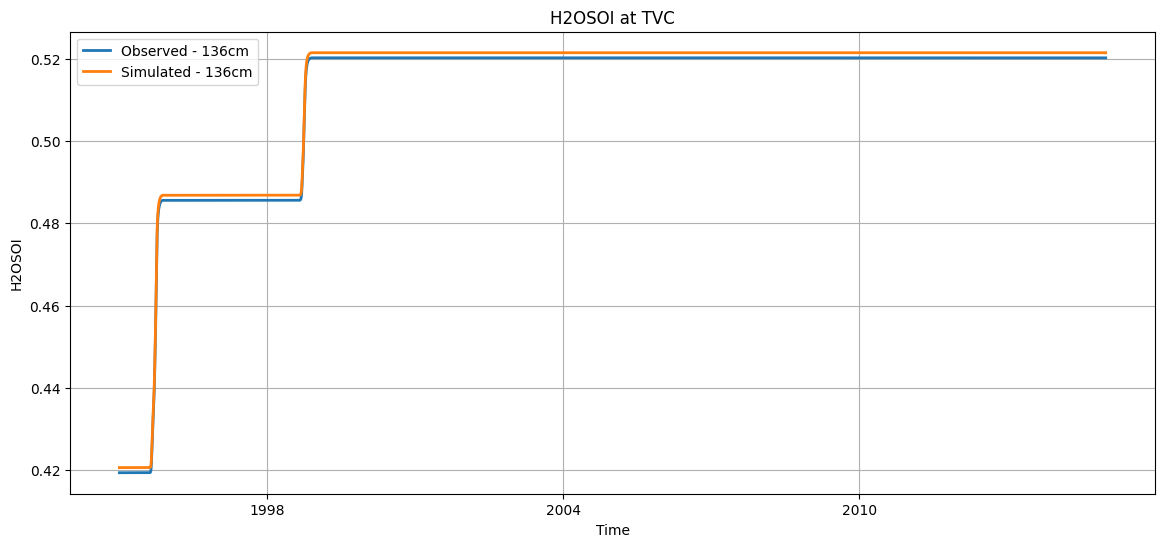

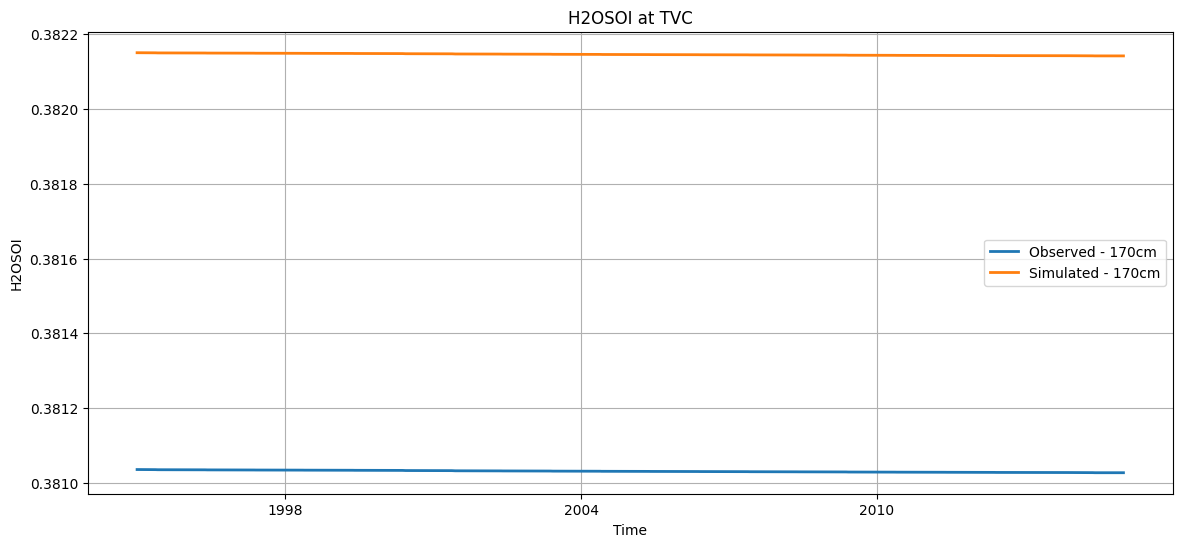

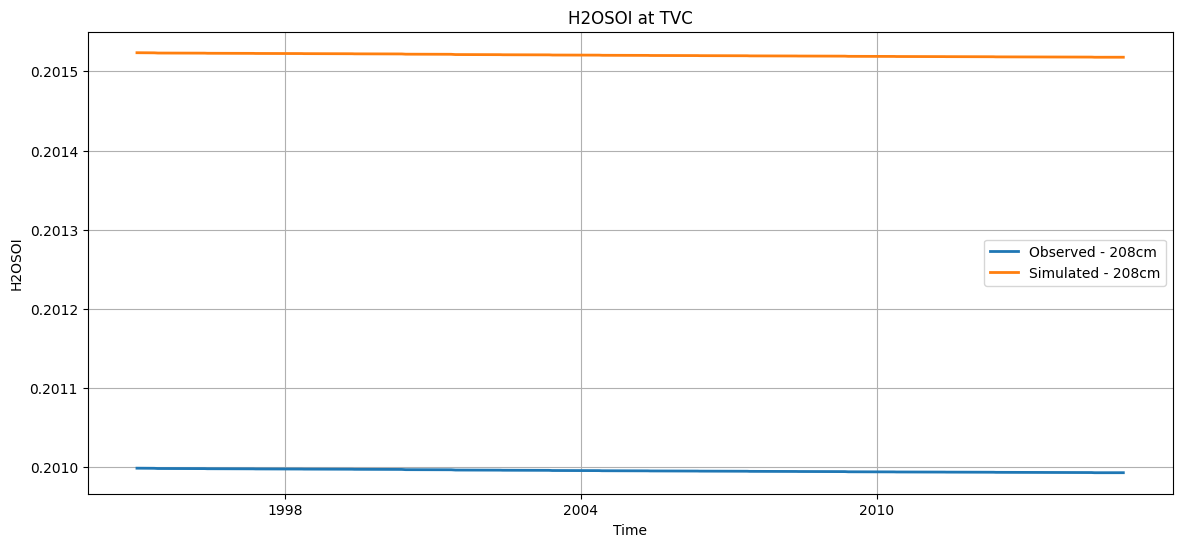

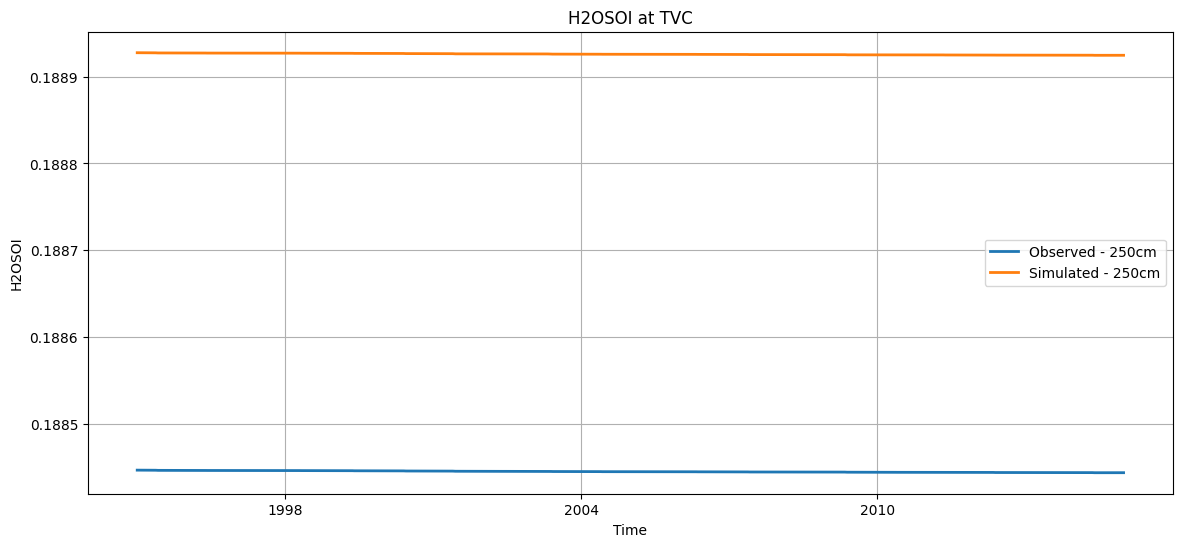

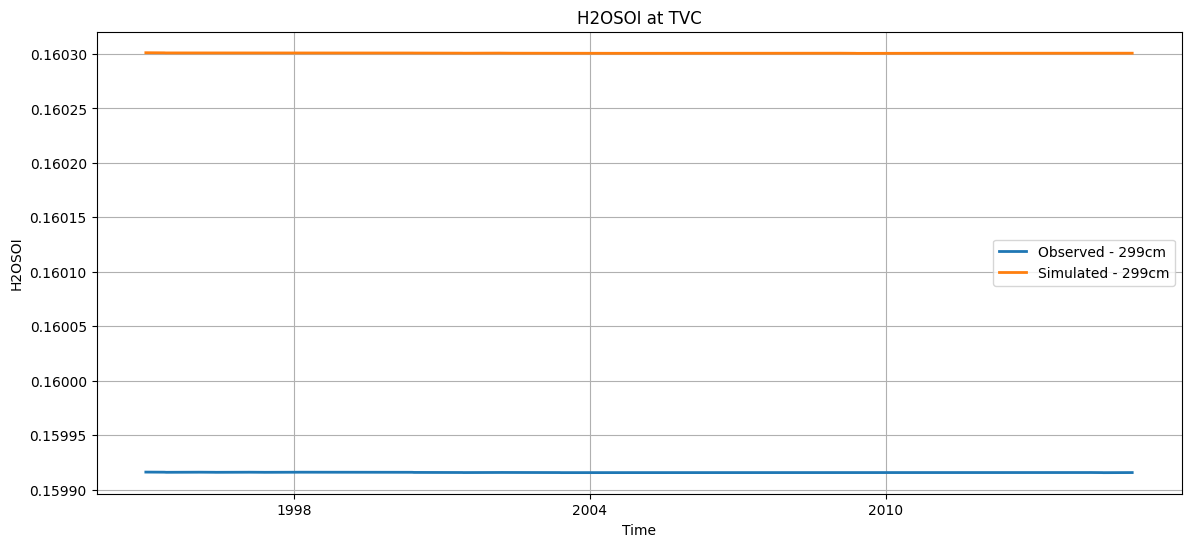

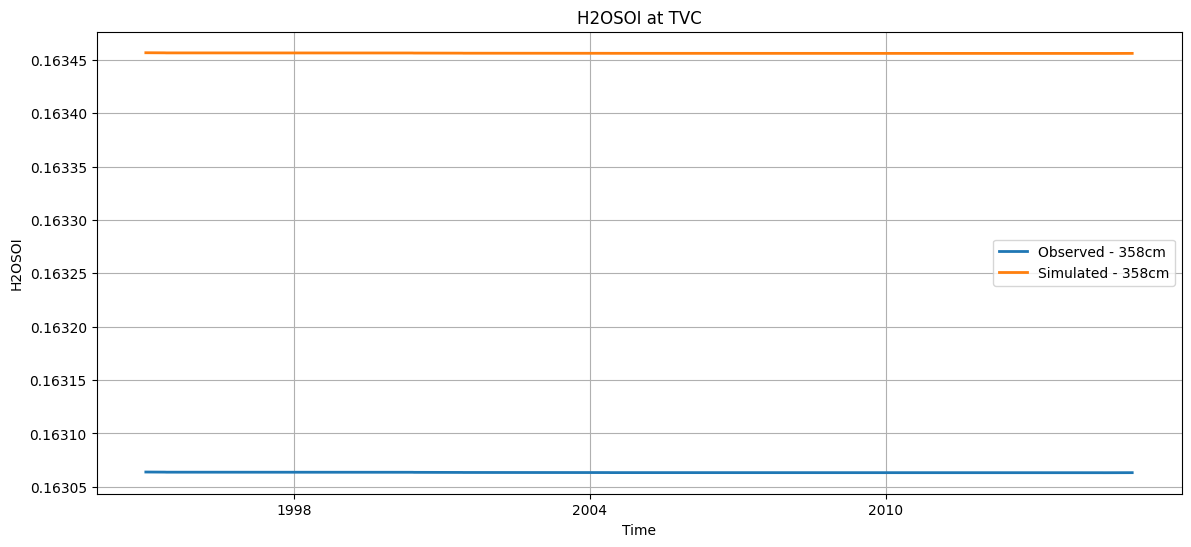

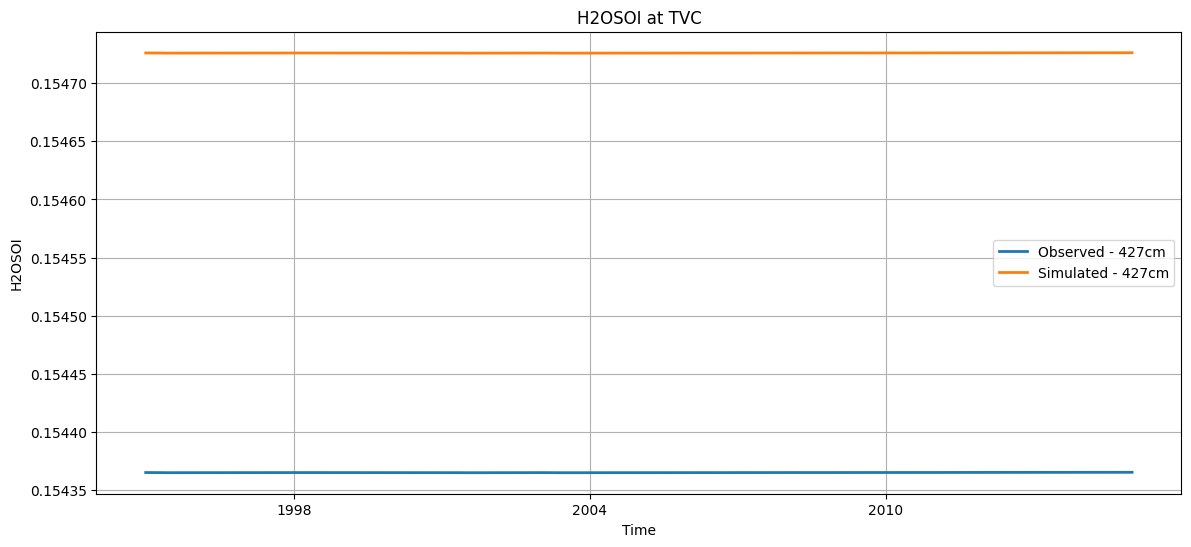

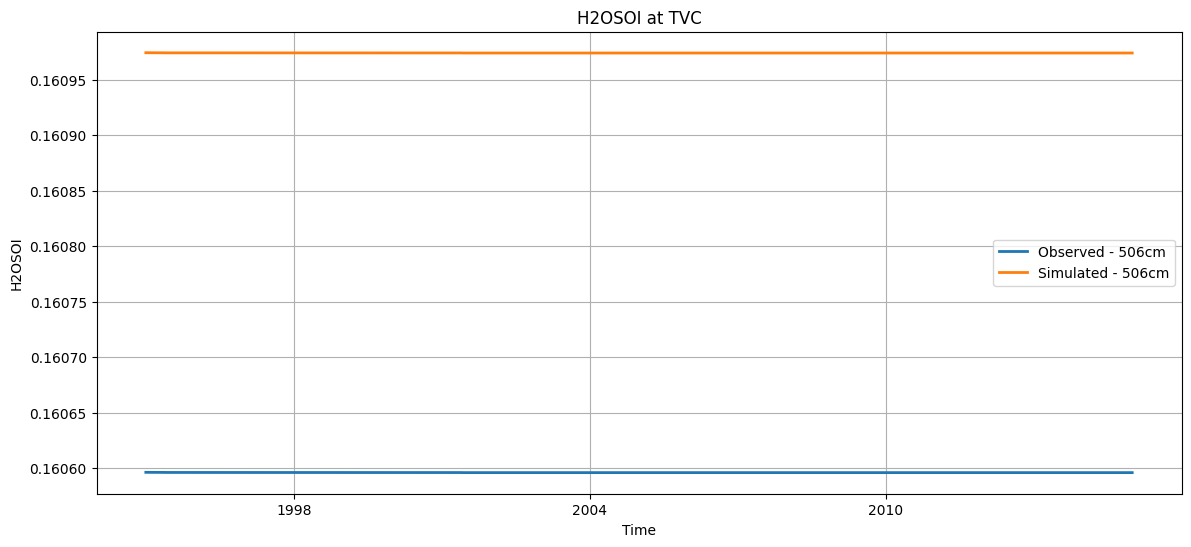

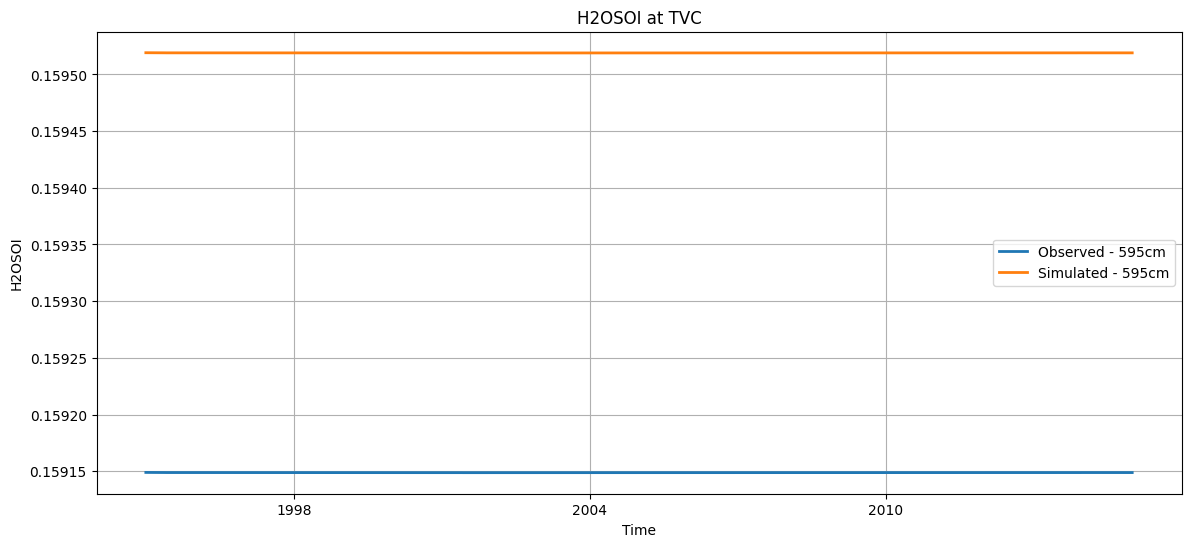

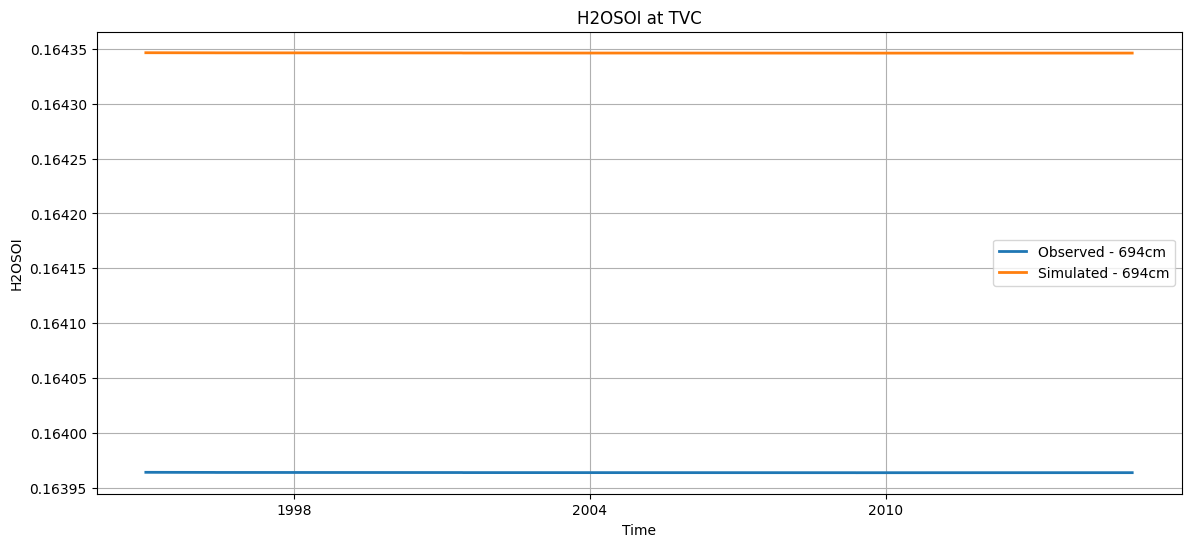

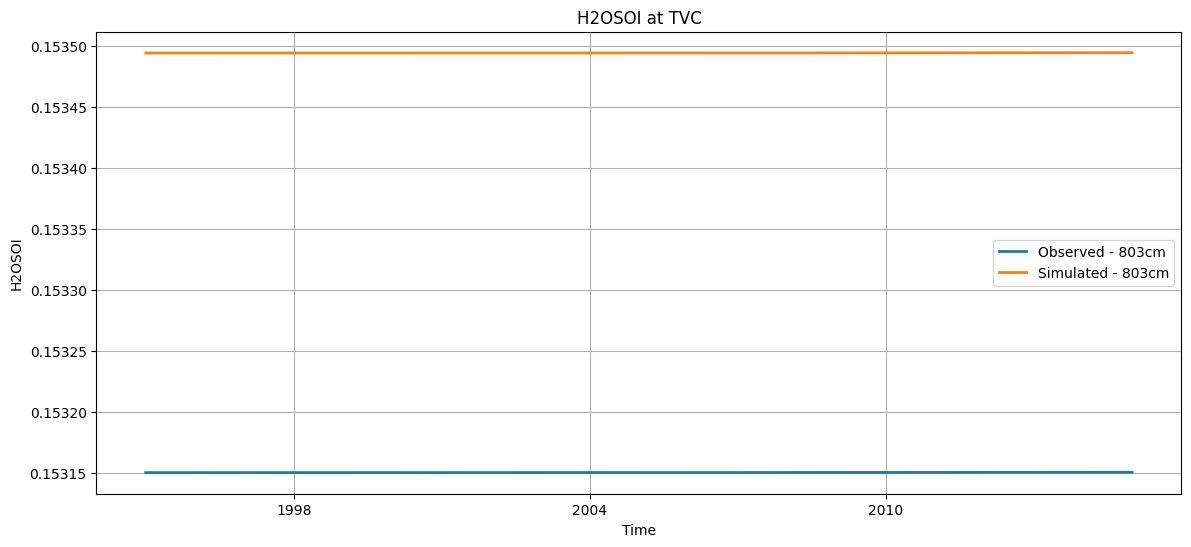

In [ ]:
plot_h2osoi(dz, ds_sm_i, ds_sm_l, ds_sm, f"{site}", ds_sm.levsoi, f"{vari}")

In [138]:
def final_plot_h2osoi(obs, sim, site, depths, vari, show=0):
    # Resample observational data to daily frequency
    obs_daily = obs.resample(time="1D").mean()

    for x in depths:

        plt.figure(figsize=(14,6))

        act_val = round(float(x.values),2)

        #print(act_val)
        # Simulated
        
        sim_depth = sim.sel(levsoi=act_val, method = "nearest").levsoi.values

        ice = sim["SOILICE"].sel(levsoi=act_val, method='nearest')
        liquid = sim["SOILLIQ"].sel(levsoi=act_val, method='nearest')
        delta = sim["DZSOI"].sel(levgrnd=act_val, method='nearest')
        h2soi = sim["H2OSOI"].sel(levsoi=act_val, method='nearest')

        liq_hsoi = liquid/1000/delta
        ice_hsoi = ice/920/delta
        convert_hsoi = (liquid/1000 + ice/920)/delta
        
        plt.plot(
            liq_hsoi["time"].values,
            liq_hsoi.values,
            label=f"Simulated liquid",
            linewidth=2
        )

        # plt.plot(
        #     ice_hsoi["time"].values,
        #     ice_hsoi.values,
        #     label=f"Simulated ice",
        #     linewidth=2
        # )

        # plt.plot(
        #     convert_hsoi["time"].values,
        #     convert_hsoi.values,
        #     label=f"Converted h2soi",
        #     linewidth=2
        # )

        # plt.plot(
        #     h2soi["time"].values,
        #     h2soi.values,
        #     label=f"Simulated h2soi",
        #     linewidth=2
        # )

        # Observed (daily)
        plt.plot(
            obs_daily["time"].values,
            obs_daily.sel(depth=x.values, method = "nearest").values,
            label=f"Observed - {act_val*100:.0f}cm",
            linewidth=2
        )

        # Labeling
        remain = int(round(x.values - act_val,3)*1000)
    
        plt.xlabel("Time")
        plt.ylabel(f"{vari}")
        plt.title(f"{vari} at {site}")
        plt.grid(True)
        plt.legend()
        if not show:
            plt.close()

C:\Users\madel\AppData\Local\Temp\ipykernel_12112\4212059848.py:6: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


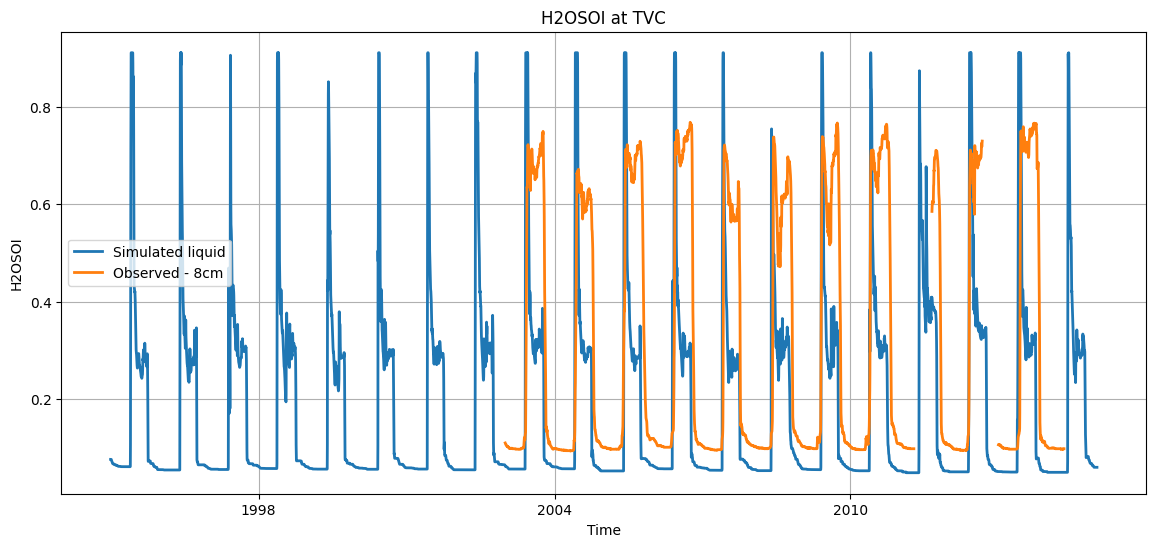

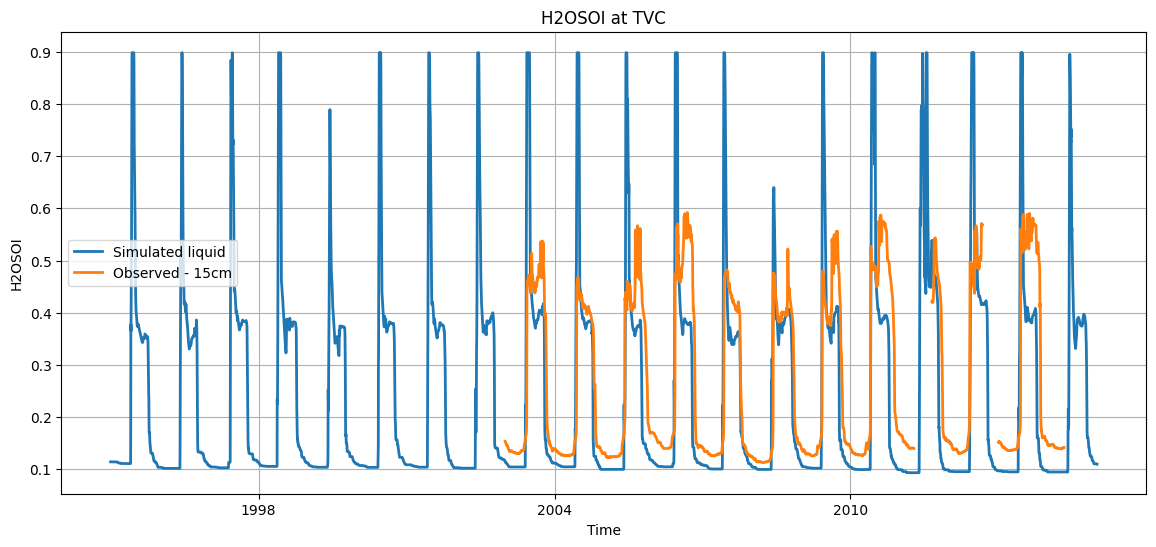

In [139]:
# next H2OSOI
site = "TVC"
vari = "H2OSOI"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"

df = xr.open_dataset(ctsm_file, engine="netcdf4")
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")

# sort for variables
ds_obs = ds[f"{vari}"]
ds_obs = ds_obs.sortby("depth")

# plot
final_plot_h2osoi(ds_obs, df, f"{site}", ds_obs.depth, f"{vari}", 1)